In [ ]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [2]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-08-31 12:00:00',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-10-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10) # add + offset to continue
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-12-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30+1 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [7]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

### Adjustment in EUC core depth

In [9]:
EUC_depth_vel = ds_tpose_TAO.UVEL.sel(YC=0,method='nearest').sel(Z=slice(0,-300)).idxmax(dim='Z')
EUC_depth_novel = ds_tpose_noTAO.UVEL.sel(YC=0,method='nearest').sel(Z=slice(0,-300)).idxmax(dim='Z')

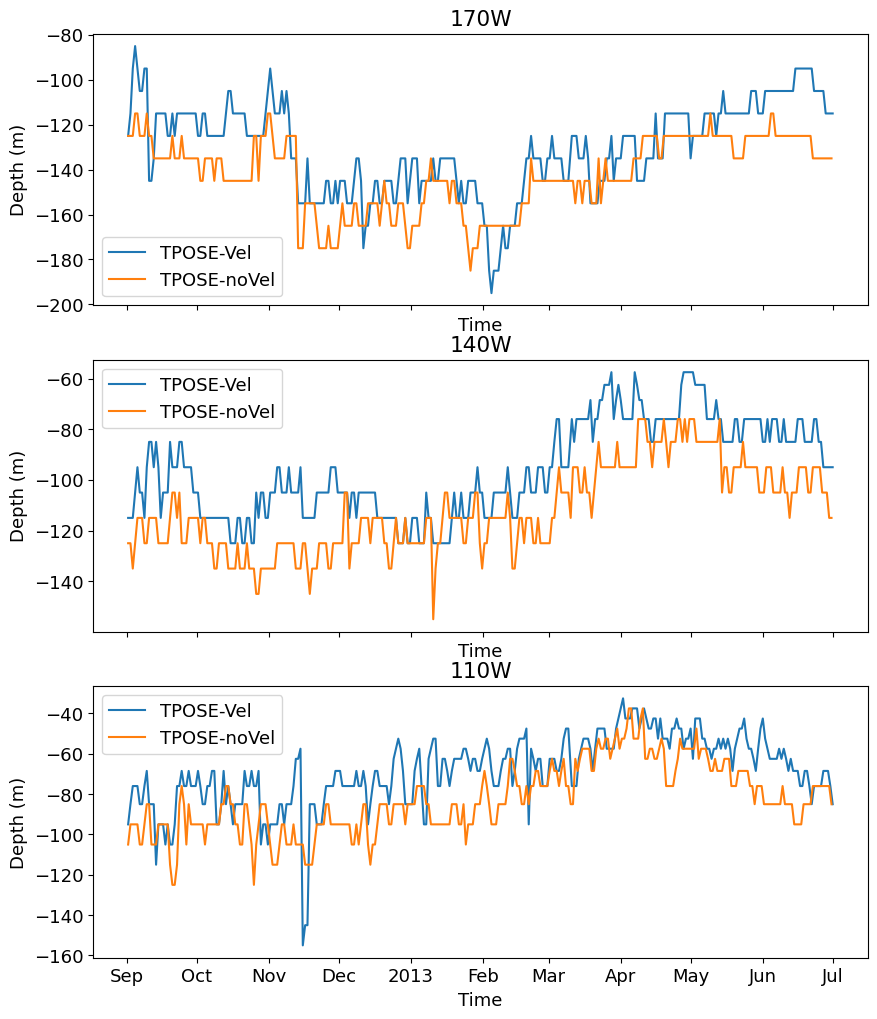

In [10]:
fig, ax = plt.subplots(figsize=(10,12),nrows=3,sharex=True)

EUC_depth_vel.sel(XG=190,method='nearest').plot(ax=ax[0],label='TPOSE-Vel')
EUC_depth_novel.sel(XG=190,method='nearest').plot(ax=ax[0],label='TPOSE-noVel')
ax[0].legend()
ax[0].set_ylabel('Depth (m)')
ax[0].set_title('170W')

EUC_depth_vel.sel(XG=220,method='nearest').plot(ax=ax[1],label='TPOSE-Vel')
EUC_depth_novel.sel(XG=220,method='nearest').plot(ax=ax[1],label='TPOSE-noVel')
ax[1].legend()
ax[1].set_ylabel('Depth (m)')
ax[1].set_title('140W')

EUC_depth_vel.sel(XG=250,method='nearest').plot(ax=ax[2],label='TPOSE-Vel')
EUC_depth_novel.sel(XG=250,method='nearest').plot(ax=ax[2],label='TPOSE-noVel')
ax[2].legend()
ax[2].set_ylabel('Depth (m)')
ax[2].set_title('110W')

plt.show()
fig.savefig(foldername + 'EUC_depth_comparison.png',dpi=300)


In [11]:
print('EUC depth with TAO assimilation - 170W: ' + str(EUC_depth_vel.sel(XG=190,method='nearest').mean().values))
print('EUC depth without TAO assimilation - 170W: ' + str(EUC_depth_novel.sel(XG=190,method='nearest').mean().values))

print('EUC depth with TAO assimilation - 140W: ' + str(EUC_depth_vel.sel(XG=220,method='nearest').mean().values))
print('EUC depth without TAO assimilation - 140W: ' + str(EUC_depth_novel.sel(XG=220,method='nearest').mean().values))

print('EUC depth with TAO assimilation - 110W: ' + str(EUC_depth_vel.sel(XG=250,method='nearest').mean().values))
print('EUC depth without TAO assimilation - 110W: ' + str(EUC_depth_novel.sel(XG=250,method='nearest').mean().values))

EUC depth with TAO assimilation - 170W: -130.4785478547855
EUC depth without TAO assimilation - 170W: -142.4917491749175
EUC depth with TAO assimilation - 140W: -96.03960396039604
EUC depth without TAO assimilation - 140W: -111.9042904290429
EUC depth with TAO assimilation - 110W: -68.75577557755776
EUC depth without TAO assimilation - 110W: -82.64026402640265


In [12]:
print('EUC depth with TAO assimilation - 180W to 100W: ' + str(EUC_depth_vel.sel(XG=slice(180,260)).mean().values))
print('EUC depth without TAO assimilation - 180W to 100W: ' + str(EUC_depth_novel.sel(XG=slice(180,260)).mean().values))

EUC depth with TAO assimilation - 180W to 100W: -102.71287814852171
EUC depth without TAO assimilation - 180W to 100W: -112.56814735527607


In [16]:
diff = EUC_depth_vel.sel(XG=190,method='nearest') - EUC_depth_novel.sel(XG=190,method='nearest')
print('max depth difference 170W ' + str(diff.max().values))

diff = EUC_depth_vel.sel(XG=220,method='nearest') - EUC_depth_novel.sel(XG=220,method='nearest')
print('max depth difference 140W ' + str(diff.max().values))

diff = EUC_depth_vel.sel(XG=250,method='nearest') - EUC_depth_novel.sel(XG=250,method='nearest')
print('max depth difference 110W ' + str(diff.max().values))

max depth difference 170W40.0
max depth difference 140W40.0
max depth difference 110W49.0


### Change in RMSD

### Change in Vertical Shear